[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter6_seminar_notebook.ipynb)

# Time Series Analysis — Seminar 6: VAR models and Granger causality

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 6; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 6 (`fit_var`, `ic_table`, `granger_F`, `girf`, `companion`, `ro_var_data`) and the seminar functions: `var1_by_hand`, `irf_by_hand`, `granger_rss`, `pair_returns`, `market_pair`, `b3_romania`.

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
SEED = 2026
GDP_SA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
ROBOR = ('irt_st_m', 'M.IRT_M3.RO')
UNEMP = ('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO')
RO_START = '2005-01-01'
RO_VARS = ['g', 'pi', 'i']
RO_P = 2
MKT = ['sp500', 'dax', 'bet']
MKT_START = '2000-01-01'
MKT_P = 4
DY_H, DY_W = 10, 200
SW_VARS = ['pi', 'u', 'R']
SW_START, SW_END, SW_P = '1960-01-01', '2000-10-01', 4
LABEL = {'g': 'GDP growth', 'pi': 'inflation', 'i': 'ROBOR 3M', 'u': 'unemployment', 'ds': 'EUR/RON change', 'R': 'fed funds rate', 'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET'}
COLV = {'g': st.Forest, 'pi': st.IDAred, 'i': st.MainBlue, 'u': st.Purple, 'ds': st.Amber, 'R': st.MainBlue, 'sp500': st.COL['sp500'], 'dax': st.COL['dax'], 'bet': st.COL['bet']}
BAND = st.Teal
WX_A = np.array([[0.5, 0.2], [0.3, 0.4]])
WX_C = np.array([1.2, 0.6])
WX_S = np.array([[1.0, 0.5], [0.5, 1.0]])
WX_Y = np.array([5.0, 2.0])
HERE = "."


def ro_monthly():
    """Romanian monthly series: 12-month HICP inflation, ROBOR 3M, unemployment rate (SA), EUR/RON (monthly mean of the
    BNR reference rate)."""
    hicp = read_eurostat(*HICP)
    fx = load_close('eurron').resample('MS').mean()
    return pd.concat([(100 * np.log(hicp).diff(12)).rename('pi'), read_eurostat(*ROBOR).rename('i'),
                      read_eurostat(*UNEMP).rename('u'), fx.rename('eurron')], axis=1)


def ro_quarterly(start=RO_START):
    """Romanian quarterly data: real GDP growth g (q/q, %, SA), 12-month HICP inflation pi, ROBOR 3M i, unemployment u
    (quarterly means of monthly data) and the EUR/RON change ds = 100 ln(S_t / S_{t-1}) of the quarterly mean rate."""
    m = ro_monthly()
    q = m.resample('QS').mean()
    g = 100 * np.log(read_eurostat(*GDP_SA)).diff()
    d = pd.concat([g.rename('g'), q['pi'], q['i'], q['u'], (100 * np.log(q['eurron']).diff()).rename('ds')], axis=1)
    d.index.name = 'date'
    return d.loc[start:].dropna(subset=['g'])


def ro_var_data(cols=RO_VARS, start=RO_START):
    return ro_quarterly(start)[cols].dropna()


def market_returns(names=MKT, start=MKT_START):
    """Daily log returns (%) of several markets on their common trading days."""
    return load_panel(names, start=start, kind='returns').dropna()


def us_sw(start=SW_START, end=None):
    """Stock and Watson (2001) data from FRED: inflation pi = 400 ln(P_t / P_{t-1}) of the chain-type GDP price index
    (GDPCTPI), the civilian unemployment rate u (UNRATE) and the federal funds rate R (FEDFUNDS), quarterly means."""
    f = read_fred(['GDPCTPI', 'UNRATE', 'FEDFUNDS'])
    pi = 400 * np.log(f['GDPCTPI'].dropna()).diff()
    d = pd.concat([pi.rename('pi'), f['UNRATE'].resample('QS').mean().rename('u'),
                   f['FEDFUNDS'].resample('QS').mean().rename('R')], axis=1).dropna()
    d.index.name = 'date'
    return d.loc[start:end]


def fit_var(d, p):
    m = VAR(d.reset_index(drop=True))
    return m.fit(p)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def qlabel(ts):
    ts = pd.Timestamp(ts)
    return f'{ts.year}Q{(ts.month - 1) // 3 + 1}'


def ccf(y, x, kmax):
    """Cross-correlations rho_yx(k) = Corr(y_t, x_{t-k}), k = -kmax..kmax (k > 0: x leads y)."""
    return {k: float(pd.Series(y).corr(pd.Series(x).shift(k))) for k in range(-kmax, kmax + 1)}


def companion(res):
    """Companion matrix of a fitted VAR(p) (Kp x Kp)."""
    K, p = res.neqs, res.k_ar
    F = np.zeros((K * p, K * p))
    F[:K, :] = np.hstack(res.coefs)
    if p > 1:
        F[K:, :-K] = np.eye(K * (p - 1))
    return F


def ic_table(d, pmax=8):
    """AIC, BIC and HQ for p = 0..pmax on a common sample (T = N - pmax):
    IC(p) = ln det Sigma_ML(p) + c_T p K^2 / T, with c_T = 2 (AIC), ln T (BIC), 2 ln ln T (HQ)."""
    Y = d.values
    K, N = Y.shape[1], len(Y)
    T = N - pmax
    out = {}
    for p in range(pmax + 1):
        X = np.column_stack([np.ones(T)] + [Y[pmax - j:N - j] for j in range(1, p + 1)])
        Z = Y[pmax:]
        B = np.linalg.lstsq(X, Z, rcond=None)[0]
        U = Z - X @ B
        ld = float(np.log(np.linalg.det(U.T @ U / T)))
        pen = p * K ** 2 / T
        out[p] = {'logdet': ld, 'aic': ld + 2 * pen, 'bic': ld + np.log(T) * pen, 'hq': ld + 2 * np.log(np.log(T)) * pen}
    best = {c: int(min(out, key=lambda p: out[p][c])) for c in ('aic', 'bic', 'hq')}
    return {'T': T, 'K': K, 'pmax': pmax, 'table': out, 'best': best}


def granger_F(d, cause, effect, p):
    """Granger causality F test in the equation of `effect` of a VAR(p) with all variables of d:
    F = [(RSS_R - RSS_U)/p] / [RSS_U/(T - Kp - 1)], RSS_R without the p lags of `cause`."""
    Y = d.values
    cols = list(d.columns)
    K, N = Y.shape[1], len(Y)
    T = N - p
    lags = [Y[p - j:N - j] for j in range(1, p + 1)]
    X = np.column_stack([np.ones(T)] + lags)
    keep = [0] + [1 + (j - 1) * K + k for j in range(1, p + 1) for k in range(K) if cols[k] != cause]
    y = Y[p:, cols.index(effect)]
    rss = lambda Xm: float(np.sum((y - Xm @ np.linalg.lstsq(Xm, y, rcond=None)[0]) ** 2))
    rss_u, rss_r = rss(X), rss(X[:, keep])
    df2 = T - K * p - 1
    F = ((rss_r - rss_u) / p) / (rss_u / df2)
    return {'F': float(F), 'p': float(stats.f.sf(F, p, df2)), 'rss_u': rss_u, 'rss_r': rss_r, 'T': T, 'df1': p,
            'df2': df2, 'crit5': float(stats.f.ppf(0.95, p, df2))}


def granger_table(d, p):
    cols = list(d.columns)
    return {f'{c}->{e}': granger_F(d, c, e, p) for c in cols for e in cols if c != e}


def girf(res, H):
    """Generalised impulse responses (Pesaran and Shin 1998): response at horizon h to a shock of one standard deviation
    in variable j, Phi_h Sigma e_j / sqrt(sigma_jj). Array (H+1, K, K): [h, response, shock]."""
    S = np.asarray(res.sigma_u)
    ma = res.ma_rep(H)
    return np.array([ma[h] @ S / np.sqrt(np.diag(S))[None, :] for h in range(H + 1)])


def gfevd(res, H=DY_H):
    """Generalised FEVD normalised by rows (Diebold and Yilmaz 2012): theta[i, j] = share of the H-step forecast error
    variance of variable i due to shocks in variable j."""
    S = np.asarray(res.sigma_u)
    ma = res.ma_rep(H - 1)
    num = sum((ma[h] @ S) ** 2 for h in range(H)) / np.diag(S)[None, :]
    den = sum(np.diag(ma[h] @ S @ ma[h].T) for h in range(H))
    th = num / den[:, None]
    return th / th.sum(axis=1, keepdims=True)


def spill_index(th):
    K = th.shape[0]
    return 100 * (th.sum() - np.trace(th)) / K


def ar_forecast(y, h, pmax=4):
    """h-step forecast of an AR(p) with constant, p chosen by AIC (p <= pmax), iterated."""
    best = min(range(1, pmax + 1), key=lambda p: AutoReg(y, lags=p, trend='c').fit().aic)
    r = AutoReg(y, lags=best, trend='c').fit()
    return float(r.forecast(h)[-1]), best


def dm_test(e1, e2, h=1):
    """Diebold-Mariano test of equal squared-error loss, with a Newey-West variance of h-1 lags; returns (DM, p)."""
    dl = np.asarray(e1) ** 2 - np.asarray(e2) ** 2
    n = len(dl)
    m = dl.mean()
    g = [np.sum((dl[k:] - m) * (dl[:n - k] - m)) / n for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = m / np.sqrt(v)
    return float(dm), float(2 * stats.norm.sf(abs(dm)))


def boot_irf(res, H, repl=500, signif=0.10, seed=SEED):
    """Residual bootstrap bands for orthogonalised impulse responses: resample the VAR residuals with replacement,
    rebuild the series from the first p observations, re-estimate the VAR(p), recompute the responses;
    percentile band of level 1 - signif."""
    rng = np.random.default_rng(seed)
    p, K = res.k_ar, res.neqs
    Y = np.asarray(res.endog)
    U = np.asarray(res.resid)
    U = U - U.mean(axis=0)
    c, A = res.intercept, res.coefs
    draws = []
    for _ in range(repl):
        y = np.zeros_like(Y)
        y[:p] = Y[:p]
        e = U[rng.integers(0, len(U), len(Y) - p)]
        for t in range(p, len(Y)):
            y[t] = c + sum(A[j] @ y[t - 1 - j] for j in range(p)) + e[t - p]
        draws.append(VAR(y).fit(p).irf(H).orth_irfs)
    draws = np.array(draws)
    return np.quantile(draws, signif / 2, axis=0), np.quantile(draws, 1 - signif / 2, axis=0)


def irf_panel(res, names, H, fname, title, repl=500, signif=0.10, save_it=True, scale=None):
    """Orthogonalised impulse responses (K x K panels) with residual-bootstrap bands."""
    irf = res.irf(H)
    lo, hi = boot_irf(res, H, repl, signif)
    K = len(names)
    fig, ax = plt.subplots(K, K, figsize=(10.0, 6.0), sharex=True)
    h = np.arange(H + 1)
    for i in range(K):
        for j in range(K):
            a = ax[i, j]
            a.fill_between(h, lo[:, i, j], hi[:, i, j], color=BAND, alpha=0.25,
                           label=f'{int(100 * (1 - signif))}% band' if (i, j) == (0, 0) else '_nolegend_')
            a.plot(h, irf.orth_irfs[:, i, j], color=COLV[names[j]], lw=1.6,
                   label='orthogonalised response' if (i, j) == (0, 0) else '_nolegend_')
            a.axhline(0, color=st.DarkText, lw=0.6)
            a.set_title(f'{LABEL[names[i]]} <- {LABEL[names[j]]} shock', fontsize=11)
            a.tick_params(labelsize=10)
            a.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    for a in ax[-1]:
        a.set_xlabel('quarters' if H < 50 else 'days', fontsize=11)
    fig.suptitle(title, fontsize=13)
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save(fname, save_it)
    return irf.orth_irfs, lo, hi


def ro_fit(p=RO_P, cols=RO_VARS):
    return fit_var(ro_var_data(cols), p)


def var1_by_hand(A, c, yT):
    """Bivariate VAR(1) y_t = c + A y_{t-1} + e_t: eigenvalues (moduli), stability, mean, forecasts for h = 1, 2."""
    A, c, yT = np.asarray(A, float), np.asarray(c, float), np.asarray(yT, float)
    lam = np.linalg.eigvals(A)
    out = {'tr': float(np.trace(A)), 'det': float(np.linalg.det(A)), 'lam_re': lam.real.tolist(), 'lam_im': lam.imag.tolist(),
           'mod': np.abs(lam).tolist(), 'stable': bool(np.abs(lam).max() < 1)}
    if out['stable']:
        out['mu'] = np.linalg.solve(np.eye(2) - A, c).tolist()
        f1 = c + A @ yT
        out['f1'], out['f2'] = f1.tolist(), (c + A @ f1).tolist()
    return out


def irf_by_hand(A, S, H=2):
    """Simple responses Phi_h = A^h, the Cholesky factor P (S = P P') in the order (y1, y2) and in the order (y2, y1),
    the orthogonalised responses Theta_h = Phi_h P and the FEVD of both variables for h = 1..H."""
    A, S = np.asarray(A, float), np.asarray(S, float)
    P = np.linalg.cholesky(S)
    Pr = np.linalg.cholesky(S[::-1, ::-1])[::-1, ::-1]        # y2 first: lower triangular in the reversed order
    Th = [np.linalg.matrix_power(A, h) @ P for h in range(H)]
    mse = np.cumsum([t ** 2 for t in Th], axis=0)
    fevd = [m / m.sum(axis=1, keepdims=True) for m in mse]
    return {'P': P.tolist(), 'P_rev': Pr.tolist(), 'Phi': [np.linalg.matrix_power(A, h).tolist() for h in range(H)],
            'Theta': [t.tolist() for t in Th], 'Theta_rev': [(np.linalg.matrix_power(A, h) @ Pr).tolist() for h in range(H)],
            'mse': [m.sum(axis=1).tolist() for m in mse], 'fevd': [f.tolist() for f in fevd]}


def granger_rss(rss_r, rss_u, T, q, k):
    """Granger F test from the residual sums of squares: q restrictions, k coefficients in the unrestricted equation."""
    F = ((rss_r - rss_u) / q) / (rss_u / (T - k))
    return {'F': F, 'p': float(stats.f.sf(F, q, T - k)), 'crit5': float(stats.f.ppf(0.95, q, T - k)), 'df2': T - k}


def pair_returns(a='sp500', b='bet', freq='D', start=MKT_START):
    """Log returns (%) of two markets on common days; freq 'W' = Friday-to-Friday weekly returns."""
    p = pd.concat([load_close(a, start=start), load_close(b, start=start)], axis=1).dropna()
    if freq == 'W':
        p = p.resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff()).dropna()


def market_pair(freq='D', fname=None, save=True):
    """B1 (daily) and B2 (weekly): lag selection, VAR(p) with p by HQ, Granger tests both ways, the cross-correlation
    at lag 1 and the generalised response of the BET to an S&P 500 shock."""
    r = pair_returns(freq=freq)
    so = VAR(r.reset_index(drop=True)).select_order(10).selected_orders
    p = max(1, int(so['hqic']))
    res = fit_var(r, p)
    G = girf(res, 5)
    c = ccf(r['bet'], r['sp500'], 5)
    out = {'T': len(r), 'first': str(r.index[0])[:10], 'last': str(r.index[-1])[:10],
           'orders': {k: int(v) for k, v in so.items()}, 'p': p,
           'sp_bet': granger_F(r, 'sp500', 'bet', p), 'bet_sp': granger_F(r, 'bet', 'sp500', p),
           'ccf1': c[1], 'ccf0': c[0], 'ccfm1': c[-1], 'girf_bet': G[:, 1, 0].tolist(),
           'coef1': float(res.params.loc['L1.sp500', 'bet']), 'se1': float(res.stderr.loc['L1.sp500', 'bet']),
           'inst_p': float(res.test_inst_causality('sp500').pvalue), 'corr_u': float(np.corrcoef(np.asarray(res.resid).T)[0, 1])}
    if fname:
        fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.4))
        k = np.arange(-5, 6)
        ax[0].bar(k, [c[j] for j in k], width=0.55, color=st.COL['bet'], label=r'Corr(BET$_t$, S&P 500$_{t-k}$)')
        b = 1.96 / np.sqrt(len(r))
        ax[0].axhline(b, color=BAND, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax[0].axhline(-b, color=BAND, ls='--', lw=0.9, label='_nolegend_')
        ax[0].axhline(0, color=st.DarkText, lw=0.6)
        ax[0].set_xlabel('lag k (days)' if freq == 'D' else 'lag k (weeks)')
        ax[0].set_title('Cross-correlations')
        ax[1].bar(np.arange(6), G[:, 1, 0], width=0.55, color=st.MainBlue, label='BET response to an S&P 500 shock')
        ax[1].axhline(0, color=st.DarkText, lw=0.6)
        ax[1].set_xlabel('days' if freq == 'D' else 'weeks')
        ax[1].set_ylabel('% return')
        ax[1].set_title(f'Generalised impulse response, VAR({p})')
        st.fig_legend_bottom(fig, ncol=3, y=-0.02)
        plt.tight_layout()
        if save:
            st.check_no_grey(fig)
            st.save_fig(fname)
        else:
            plt.show()
    return out


def b3_romania(save=True):
    """B3: the Romanian VAR (GDP growth, inflation, ROBOR 3M): lag selection, VAR(2), stability, Portmanteau, Granger
    tests, the response of ROBOR to an inflation shock with bootstrap bands and the FEVD of ROBOR."""
    d = ro_var_data()
    ic = ic_table(d, 6)
    res = fit_var(d, RO_P)
    mod = float(np.abs(np.linalg.eigvals(companion(res))).max())
    lb = {h: res.test_whiteness(nlags=h, adjusted=True) for h in (8, 12)}
    G = granger_table(d, RO_P)
    irf = res.irf(12).orth_irfs
    lo, hi = boot_irf(res, 12, 500, 0.10)
    fe = res.fevd(12).decomp
    if save is not None:
        fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.4))
        h = np.arange(13)
        ax[0].fill_between(h, lo[:, 2, 1], hi[:, 2, 1], color=BAND, alpha=0.25, label='90% bootstrap band')
        ax[0].plot(h, irf[:, 2, 1], 'o-', ms=3.5, color=st.IDAred, label='ROBOR 3M response to an inflation shock')
        ax[0].axhline(0, color=st.DarkText, lw=0.6)
        ax[0].set_xlabel('quarters')
        ax[0].set_ylabel('percentage points')
        ax[0].set_title('Orthogonalised response (order g, inflation, ROBOR)')
        bottom = np.zeros(12)
        for j, s in enumerate(['g', 'pi', 'i']):
            ax[1].bar(np.arange(1, 13), 100 * fe[2, :, j], bottom=bottom, color=COLV[s], width=0.75,
                      label=f'{LABEL[s]} shock')
            bottom += 100 * fe[2, :, j]
        ax[1].set_xlabel('horizon (quarters)')
        ax[1].set_ylabel('%')
        ax[1].set_title('FEVD of ROBOR 3M')
        st.fig_legend_bottom(fig, ncol=3, y=-0.02)
        plt.tight_layout()
        if save:
            st.check_no_grey(fig)
            st.save_fig('ch6_sem_b3')
        else:
            plt.show()
    return {'ic': ic, 'max_mod': mod, 'nobs': int(res.nobs), 'first': str(d.index[0])[:10], 'last': str(d.index[-1])[:10],
            'lb': {h: {'stat': float(w.test_statistic), 'df': int(w.df), 'p': float(w.pvalue)} for h, w in lb.items()},
            'granger': {k: {'F': v['F'], 'p': v['p']} for k, v in G.items()}, 'crit5': G['g->i']['crit5'],
            'i_pi': irf[:, 2, 1].tolist(), 'i_pi_lo': lo[:, 2, 1].tolist(), 'i_pi_hi': hi[:, 2, 1].tolist(),
            'fevd_i': {str(k): (100 * fe[2, k - 1, :]).tolist() for k in (1, 4, 8, 12)}}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: a VAR(1) by hand

**Context.** $\mathbf{c} = (0.4, 0.8)'$, $\mathbf{A} = \begin{pmatrix} 0.6 & 0.2 \\ 0.2 & 0.6 \end{pmatrix}$, $\mathbf{Y}_T = (3, 2)'$.

1. Write the two equations.
2. Find the eigenvalues of $\mathbf{A}$ and decide whether the VAR is stable.
3. Compute the mean $\boldsymbol{\mu}$.
4. Compute $\hat{\mathbf{Y}}_{T+1}$ and $\hat{\mathbf{Y}}_{T+2}$.

**Report:** two equations, two eigenvalues, $\boldsymbol{\mu}$, two forecasts.

In [7]:
# Solution
var1_by_hand([[0.6, 0.2], [0.2, 0.6]], [0.4, 0.8], [3.0, 2.0])

{'tr': 1.2,
 'det': 0.32,
 'lam_re': [0.7999999999999999, 0.3999999999999999],
 'lam_im': [0.0, 0.0],
 'mod': [0.7999999999999999, 0.3999999999999999],
 'stable': True,
 'mu': [2.6666666666666665, 3.333333333333333],
 'f1': [2.5999999999999996, 2.6],
 'f2': [2.48, 2.88]}

**Interpretation of the result.** Eigenvalues 0.8 and 0.4: stable. The forecasts (2.6, 2.6) and (2.48, 2.88) move towards the mean (2.67, 3.33).

## A2 [Proposed]: stable or not?

**Context.** (a) $\mathbf{A} = \begin{pmatrix} 0.9 & 0.3 \\ 0.2 & 0.8 \end{pmatrix}$; (b) $\mathbf{A} = \begin{pmatrix} 0.5 & -0.4 \\ 0.4 & 0.5 \end{pmatrix}$. Model: A1.

1. For each matrix, compute the trace, the determinant and the eigenvalues.
2. Decide whether each VAR is stable.
3. Describe how the responses to a shock behave in each case.

**Report:** four eigenvalues (or moduli), two decisions and two sentences.

In [ ]:
# Your code here


## A3 [Solved]: orthogonalised impulse responses

**Context.** The VAR(1) of A1 with $\boldsymbol{\Sigma} = \begin{pmatrix} 1 & 0.4 \\ 0.4 & 1 \end{pmatrix}$.

1. Compute the Cholesky factor $\mathbf{P}$.
2. Compute $\boldsymbol{\Theta}_0 = \mathbf{P}$, $\boldsymbol{\Theta}_1 = \mathbf{A}\mathbf{P}$ and $\boldsymbol{\Phi}_2 = \mathbf{A}^2$.
3. Compute $\mathbf{P}$ again with the order $(y_2, y_1)$ and say what changes on impact.

**Report:** three matrices and one sentence.

In [9]:
# Solution
r = irf_by_hand([[0.6, 0.2], [0.2, 0.6]], [[1.0, 0.4], [0.4, 1.0]], 3)
print('P =', np.round(r['P'], 3))
print('Theta_1 =', np.round(r['Theta'][1], 3))
print('Phi_2 =', np.round(r['Phi'][2], 3))
print('P, order (y2, y1) =', np.round(r['P_rev'], 3))

P = [[1.    0.   ]
 [0.4   0.917]]
Theta_1 = [[0.68  0.183]
 [0.44  0.55 ]]
Phi_2 = [[0.4  0.24]
 [0.24 0.4 ]]
P, order (y2, y1) = [[0.917 0.4  ]
 [0.    1.   ]]


**Interpretation of the result.** With $y_1$ first, a shock $u_1$ moves $y_2$ by 0.4 at once; with $y_2$ first, it is $y_1$ that reacts on impact to the shock of $y_2$.

## A4 [Proposed]: a variance decomposition by hand

**Context.** $\boldsymbol{\Theta}_0$ and $\boldsymbol{\Theta}_1$ of A3. Model: A3.

1. Compute the share of $u_1$ in the 1-step forecast error variance of $y_2$.
2. Compute the 2-step forecast error variance of $y_2$ and the share of $u_1$ in it.
3. Compute the share of $u_2$ in the 2-step error variance of $y_1$, and explain why it is 0 at one step.

**Report:** three percentages and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: a Granger $F$ test

**Context.** A bivariate VAR(2), $T = 100$; equation of $y_1$: $RSS_U = 45.2$, $RSS_R = 52.8$.

1. Give $H_0$, the number of restrictions $q$ and the number of coefficients $k$.
2. Compute $F$.
3. Decide at 5% and state the conclusion in words.

**Report:** $H_0$, $F$, a decision and one sentence.

In [11]:
# Solution
granger_rss(52.8, 45.2, 100, 2, 5)

{'F': 7.986725663716808,
 'p': 0.0006222491803106987,
 'crit5': 3.0922174387023635,
 'df2': 95}

**Interpretation of the result.** $F \approx 7.99 > 3.09$: the lags of $y_2$ help to forecast $y_1$.

## A6 [Proposed]: choosing $p$ by hand

**Context.** $K = 3$, $T = 80$, $\ln\det\tilde{\boldsymbol{\Sigma}}(p) = 1.50, 0.60, 0.25, 0.00, -0.15$ for $p = 0..4$. Model: A5.

1. Compute the penalty per lag for AIC, BIC and HQ.
2. Compute the three criteria for each $p$ and find the minima.
3. Say which $p$ you would start from with 80 quarters, and why.

**Report:** three penalties, a table of 15 values, three orders and one sentence.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: does the S&P 500 lead the BET?

**Question.** Do yesterday's S&P 500 returns help to forecast today's BET returns, and the other way round?

1. Compute the cross-correlations $\mathrm{Corr}(\mathrm{BET}_t, \mathrm{S\&P}_{t-k})$, $k = -5..5$.
2. Choose $p$ with AIC, BIC and HQ (maximum 10) and estimate the VAR with the HQ order.
3. Test Granger causality in both directions.
4. Compute the generalised response of the BET to an S&P 500 shock for 5 days.
5. Interpretation: why does New York lead Bucharest by one day?

**Report:** three cross-correlations, the chosen $p$, two $F$ tests, two responses and one sentence.

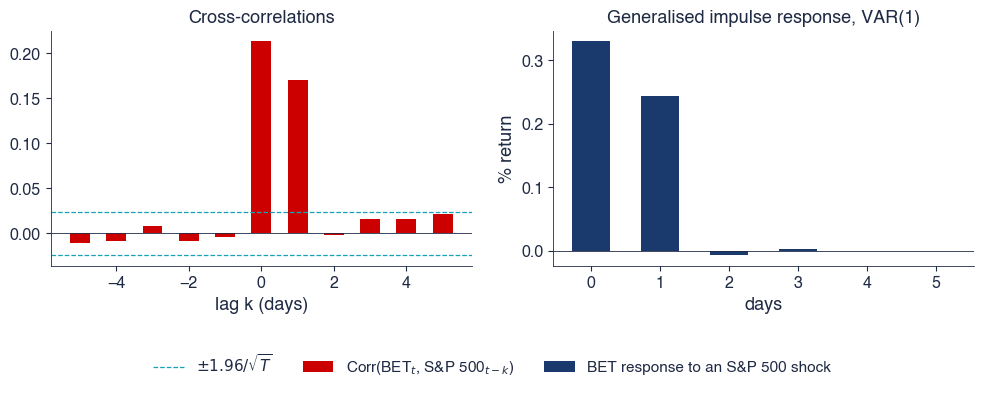

orders: {'aic': 9, 'bic': 1, 'hqic': 1, 'fpe': 9} p = 1
S&P -> BET: 156.2 1.9448584330332614e-35
BET -> S&P: 2.25 0.133
GIRF of the BET: [ 0.329  0.243 -0.007  0.003 -0.     0.   ]


In [13]:
# Solution
b1 = market_pair('D', 'ch6_sem_b1', save=False)
print('orders:', b1['orders'], 'p =', b1['p'])
print('S&P -> BET:', round(b1['sp_bet']['F'], 1), b1['sp_bet']['p'])
print('BET -> S&P:', round(b1['bet_sp']['F'], 2), round(b1['bet_sp']['p'], 3))
print('GIRF of the BET:', np.round(b1['girf_bet'], 3))

**Interpretation of the result.** The S&P 500 Granger-causes the BET and not the reverse. Wall Street closes after Bucharest, so the American afternoon is priced in Bucharest the next day: a time-zone effect.

## B2 [Proposed]: the same question with weekly returns

**Question.** Does the lead of the S&P 500 survive with Friday-to-Friday weekly returns? Model: B1.

1. Repeat steps 1–4 of B1 on weekly returns (`market_pair('W', ...)`).
2. Compare the lag-1 cross-correlation and the $F$ statistic with the daily ones.
3. Interpretation: why is the lead much weaker at the weekly frequency?

**Report:** the same items as in B1 and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: a VAR for the Romanian economy

**Question.** How do GDP growth, inflation and the 3-month interest rate interact in Romania?

1. Choose $p$ with AIC, BIC and HQ ($p \le 6$) and estimate a VAR(2).
2. Check stability and run the portmanteau test with $h = 8$ and $h = 12$.
3. Run the six Granger $F$ tests.
4. Plot the orthogonalised response of ROBOR to an inflation shock and the FEVD of ROBOR.
5. Interpretation: do the results show that the central bank reacts to inflation?

**Report:** three orders, one modulus, two portmanteau tests, a table of six tests, the chart and one sentence.

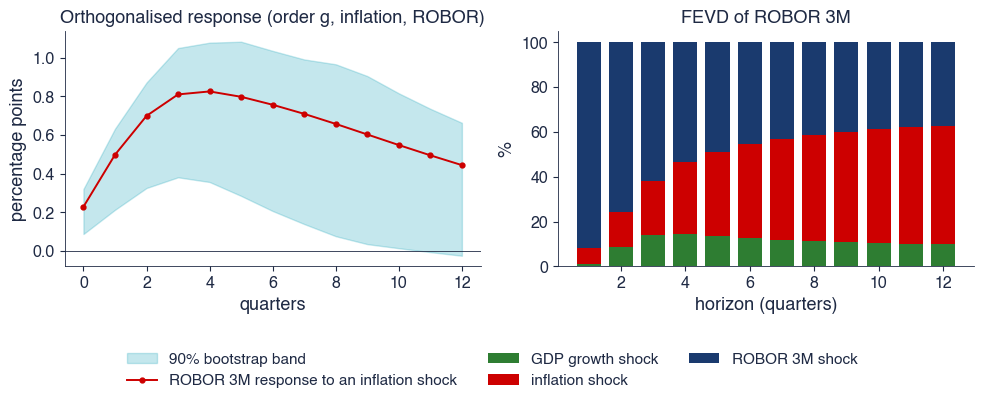

orders: {'aic': 5, 'bic': 1, 'hq': 2} largest modulus: 0.869
portmanteau: {8: {'stat': 76.67994664151918, 'df': 54, 'p': 0.0228968422447569}, 12: {'stat': 105.25684786637639, 'df': 90, 'p': 0.12973155919231041}}
              F         p
g->pi  0.159424  0.852916
g->i   7.264296  0.001288
pi->g  2.941855  0.058726
pi->i  4.742770  0.011417
i->g   4.016254  0.021922
i->pi  0.885172  0.416800
FEVD of ROBOR: {'1': [1.2412098579994089, 6.960588547000908, 91.79820159499968], '4': [14.387205585711246, 32.036481367249664, 53.57631304703909], '8': [11.25388141652551, 47.31708296783098, 41.42903561564351], '12': [9.907883021026805, 52.79405930354998, 37.2980576754232]}


In [15]:
# Solution
b3 = b3_romania(save=False)
print('orders:', b3['ic']['best'], 'largest modulus:', round(b3['max_mod'], 3))
print('portmanteau:', b3['lb'])
print(pd.DataFrame(b3['granger']).T)
print('FEVD of ROBOR:', b3['fevd_i'])

**Interpretation of the result.** ROBOR follows inflation (Granger test, impulse response, FEVD), as a reaction function would imply. ROBOR is a market rate, so the VAR cannot separate the central bank's decisions from market expectations.

## B4 [Proposed]: adding the EUR/RON exchange rate

**Question.** Does the depreciation of the leu help to forecast inflation? Model: B3.

1. Choose $p$ with the three criteria ($p \le 4$) for `ro_var_data(['g', 'ds', 'pi', 'i'])` and estimate a VAR(2).
2. Test whether `ds` Granger-causes `pi`, `i` and `g`, and whether `i` and `pi` Granger-cause `ds`.
3. Compute the share of EUR/RON shocks in the FEVD of inflation at 1, 4, 8 and 12 quarters.
4. Interpretation: does the result mean that the exchange rate does not affect Romanian prices?

**Report:** three orders, five $F$ tests, four shares and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: the price puzzle

**Question.** Why does inflation rise after a ROBOR shock in the VAR of B3, and does it change with the exchange rate or more lags? Models: B3, B4.

1. Plot the response of inflation to a ROBOR shock in the VAR(2) of B3, the VAR(2) of B4 and a VAR(4) with the four variables of B4.
2. Report the largest and the smallest response and their horizons.
3. List two pieces of information that the central bank has and the VAR does not.
4. Interpretation: is a positive response of inflation a proof that higher rates raise prices?

**Report:** the chart, six numbers and a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant analysed the VAR of B3. It answered:

- (a) AIC chooses p = 5, so the true lag order of the economy is 5;
- (b) the largest eigenvalue modulus of A1 is above 1, so the VAR(2) is explosive;
- (c) the portmanteau test at 8 lags has a p-value of about 0.02, so the residuals are white noise;
- (d) GDP growth Granger-causes ROBOR, so faster growth causes the BNR to raise rates;
- (e) Cholesky impulse responses do not depend on the order of the variables;
- (f) in each row of the FEVD the shares add up to 100%.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
